In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import bootstrap
from numba import njit
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import LeaveOneOut, GridSearchCV

ds = np.loadtxt('sdss_cutout.csv', skiprows=1, delimiter=',')

In [2]:
ds_panda = pd.read_csv('sdss_cutout.csv')
ds_panda

,RA,DEC,Z,phot_u,phot_g,phot_r,phot_i,phot_z
0,130.089951,52.178097,0.097629,19.854843,18.159964,17.345013,16.930433,16.620535
1,130.173909,52.557767,0.067737,19.250399,17.239248,16.517265,16.083832,15.822161
2,130.081237,52.668188,0.063350,18.680342,17.206959,16.697826,16.362032,16.173033
3,130.291706,52.572373,0.065425,19.726742,17.791235,16.906610,16.495539,16.182104
4,130.013537,52.766588,0.123360,19.386818,17.534359,16.450377,15.943369,15.545097
...,...,...,...,...,...,...,...,...
319953,149.580633,47.033396,0.390038,23.223936,19.346468,17.534588,16.857544,16.351515
319954,150.261929,46.827647,0.204686,20.360432,18.511255,17.276648,16.812563,16.496658
319955,149.937963,46.482358,0.102099,19.087252,17.185118,16.237055,15.844631,15.480799
319956,150.023597,46.260926,0.069142,19.072407,17.949339,17.497790,17.227016,17.132250


Q1

In [3]:
ds2 = np.array([ds[0,:]])
for n in range(1, np.shape(ds)[0]):
    if (ds[n,2] < 0.105 and ds[n,2] > 0.095):
        ds2 = np.append(ds2, np.array([ds[n,:]]), axis = 0)
        
ds1 = np.array([ds[0,:]])
for n in range(1, np.shape(ds)[0]):
    if (ds[n,2] < 0.12 and ds[n,2] > 0.08):
        ds1 = np.append(ds1, np.array([ds[n,:]]), axis = 0)        

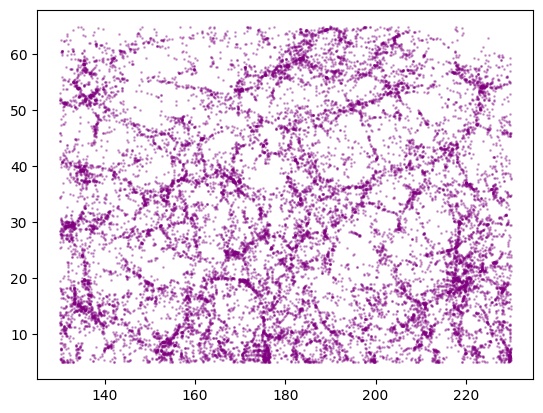

In [4]:
plt.scatter(ds2[:,0], ds2[:,1], s=1, alpha=0.3, color = "purple")

In [5]:
u_r = ds2[:, 3] - ds2[:, 5]

ds2 = np.column_stack((ds2, u_r))
u_r_1 = ds1[:, 3] - ds1[:, 5]

ds1 = np.column_stack((ds1, u_r_1))
redgalaxies = ds2[:, 8:9] > 2.3
bluegalaxies = ds2[:, 8:9] <= 2.3
redgalaxies = ds2[redgalaxies[:,0]]
bluegalaxies = ds2[bluegalaxies[:,0]]

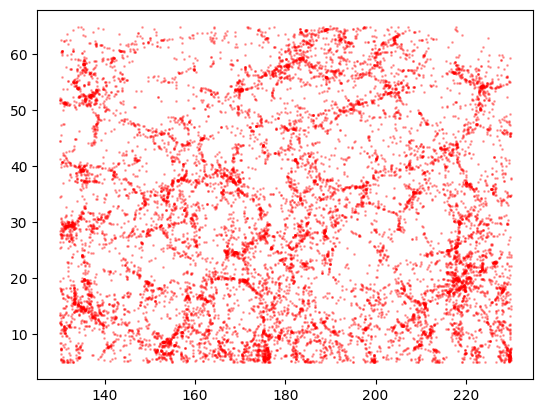

In [6]:
plt.scatter(redgalaxies[:,0], redgalaxies[:,1], s=1, alpha=0.3, color = "red")

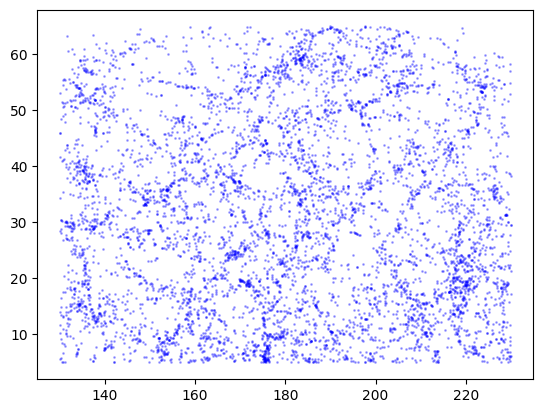

In [7]:
plt.scatter(bluegalaxies[:,0], bluegalaxies[:,1], s=1, alpha=0.3, color = "blue")

In [8]:
print(ds2[:, 0].min(), ds2[:, 0].max())  # RA range
print(ds2[:, 1].min(), ds2[:, 1].max())  # DEC range
print(ds2.shape)                          # how many galaxies

130.00716750663128 229.99580238242615
5.002095975017483 64.9815952201038
(20325, 9)


Q2

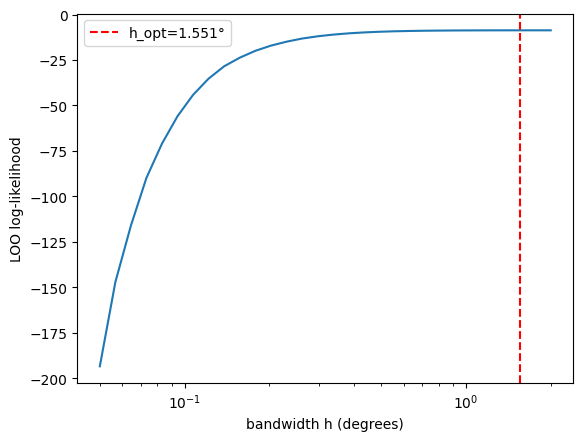

h_opt  = 1.551°
h_silv = 5.046°


In [11]:

# downsample to make LOO feasible
np.random.seed(42)
idx = np.random.choice(len(ds1), size=2000, replace=False)
Xdata = ds1[idx, :2]  # just RA and DEC, shape (2000, 2)

# LOO grid search
bandwidths = np.geomspace(0.05, 2.0, 30)
grid = GridSearchCV(KernelDensity(kernel='gaussian'),
                    {'bandwidth': bandwidths}, cv=LeaveOneOut())
grid.fit(Xdata)
loo_scores = grid.cv_results_['mean_test_score']
h_opt = grid.best_params_['bandwidth']
plt.plot(bandwidths, loo_scores)
plt.xscale('log')
plt.axvline(h_opt, color='r', linestyle='--', label=f'h_opt={h_opt:.3f}°')
plt.xlabel('bandwidth h (degrees)')
plt.ylabel('LOO log-likelihood')
plt.legend()
plt.show()
 

# Silverman's rule: sigma = geometric mean of marginal stds
sigma = np.sqrt(np.std(Xdata[:,0]) * np.std(Xdata[:,1]))
N = len(Xdata)
h_silv = 1.06 * sigma * N**(-1/5)
print(f"h_opt  = {h_opt:.3f}°")
print(f"h_silv = {h_silv:.3f}°")

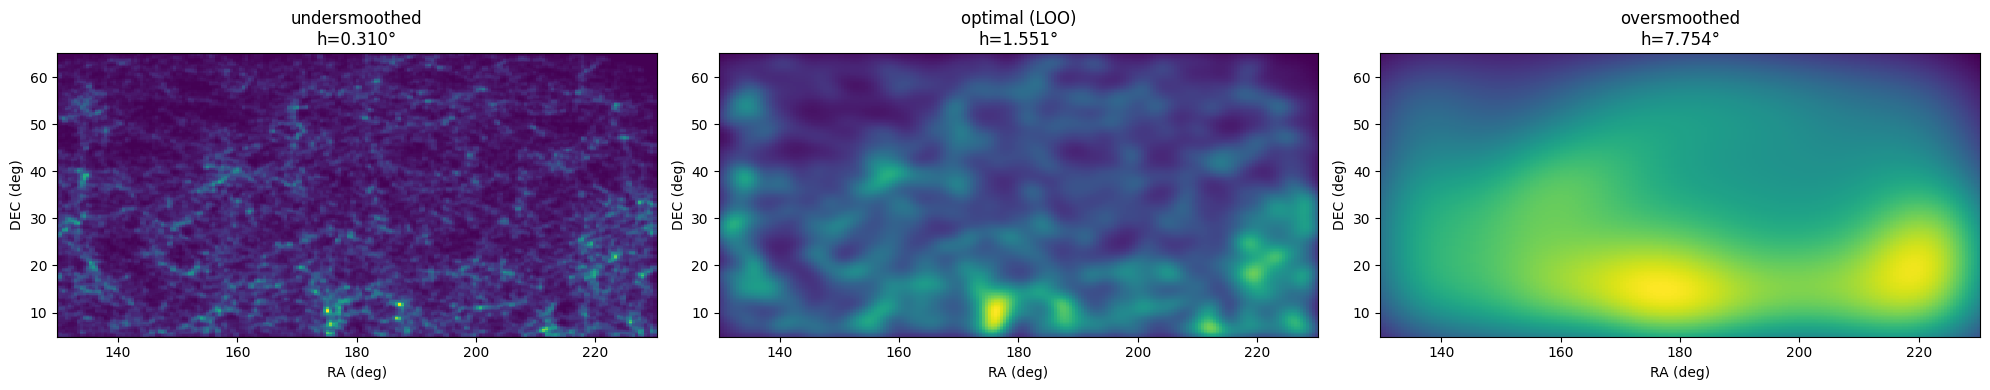

In [ ]:
# fit final models on full Xdata (all galaxies, not downsampled)
Xdata_full = ds1[:, :2]

bandwidths_to_plot = [h_opt/5, h_opt, h_opt*5]
titles = [f'undersmoothed\nh={h_opt/5:.3f}°', 
          f'optimal (LOO)\nh={h_opt:.3f}°', 
          f'oversmoothed\nh={h_opt*5:.3f}°']

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

n1, n2 = 200, 200
v1min, v1max = Xdata_full[:, 0].min(), Xdata_full[:, 0].max()
v2min, v2max = Xdata_full[:, 1].min(), Xdata_full[:, 1].max()

v1g = np.linspace(v1min, v1max, n1)
v2g = np.linspace(v2min, v2max, n2)
xg, yg = np.meshgrid(v1g, v2g)
Xgrid = np.vstack((xg.flatten(), yg.flatten())).T

for ax, h, title in zip(axes, bandwidths_to_plot, titles):,
    model = KernelDensity(kernel='gaussian', bandwidth=h)
    model.fit(Xdata_full)
    kde_dens_at_x = np.exp(model.score_samples(Xgrid))
    ptest = kde_dens_at_x.reshape((n2, n1))
    ax.pcolor(v1g, v2g, ptest, cmap='viridis')
    ax.set_xlabel('RA (deg)')
    ax.set_ylabel('DEC (deg)')
    ax.set_title(title)

plt.tight_layout()
plt.show()

Q3

n=1, BIC=129388.60
n=2, BIC=111316.75
n=3, BIC=111696.97
n=4, BIC=104441.33
n=5, BIC=102738.67
n=6, BIC=102601.70


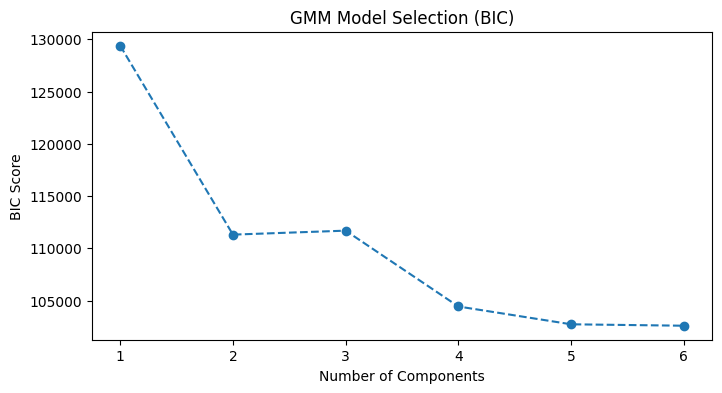

In [13]:

bics = []
n_components = range(1, 7)
for n in n_components:
    gmm = GaussianMixture(n_components=n, covariance_type='full',n_init=100, random_state=31,
    reg_covar=1e-3)  # add small regularization to avoid singular covariances
    gmm.fit(ds1[:,8:9])
    bic = gmm.bic(ds1[:,8:9])
    aic = gmm.aic(ds1[:,8:9])
    bics.append(bic)
    print(f"n={n}, BIC={bic:.2f}")
plt.figure(figsize=(8, 4))
plt.plot(n_components, bics, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('BIC Score')
plt.title('GMM Model Selection (BIC)')
plt.show()
    

Biggest drop is at 2 with 18071 and second drop is at 4 with 7255 after K=4 the drop or becomes either negligable or it turns into an increase.

In [14]:
Diff_bics = np.diff(bics) 
print("BIC differences at steps:", Diff_bics)

BIC differences at steps: [-18071.84692794    380.21729484  -7255.63497374  -1702.66461213
   -136.97214519]


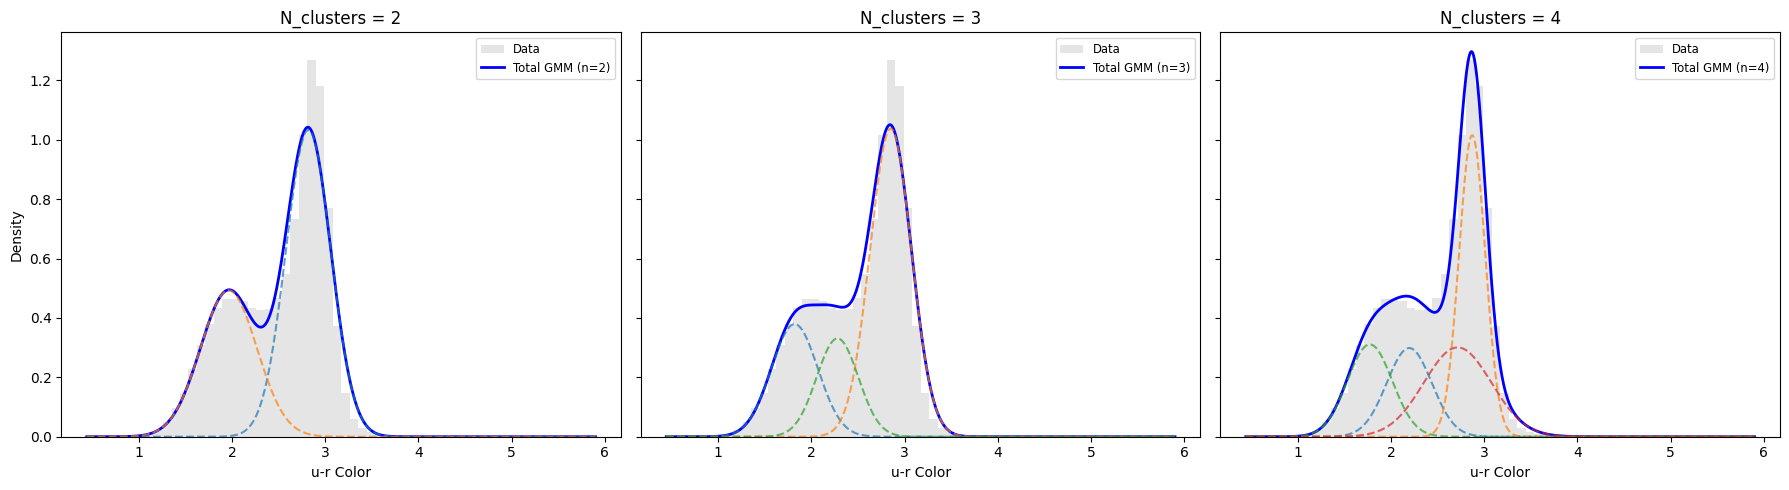

In [15]:
# 1. Define the number of components you want to compare
n_values = [2,3,4]
models = {}  # Dictionary to store the fitted models for later use

# 2. Setup the figure for subplots
fig, axes = plt.subplots(1, len(n_values), figsize=(18, 5), sharey=True)
x_plot = np.linspace(ds1[:, 8].min(), ds1[:, 8].max(), 1000).reshape(-1, 1)

for i, n in enumerate(n_values):
    # Fit the model
    gmm = GaussianMixture(n_components=n, n_init=20, random_state=31).fit(ds1[:, 8].reshape(-1, 1))
    models[n] = gmm # Save to our list/dictionary
    
    # Calculate density
    log_density = gmm.score_samples(x_plot)
    total_density = np.exp(log_density)
    
    # Plotting on the specific subplot (axes[i])
    ax = axes[i]
    ax.hist(ds1[:, 8], bins=60, density=True, alpha=0.2, color='gray', label='Data')
    ax.plot(x_plot, total_density, color='blue', lw=2, label=f'Total GMM (n={n})')
    
    # Plot individual components
    resp = gmm.predict_proba(x_plot)
    individual_densities = resp * total_density[:, np.newaxis]
    for j in range(n):
        ax.plot(x_plot, individual_densities[:, j], '--', alpha=0.7)
        
    ax.set_title(f'N_clusters = {n}')
    ax.set_xlabel('u-r Color')
    if i == 0: ax.set_ylabel('Density')
    ax.legend(fontsize='small')

plt.tight_layout()
plt.show()

In [16]:
chosen_n = 2
chosen_model = GaussianMixture(n_components=chosen_n, covariance_type='full', n_init=20, random_state=31)
chosen_model.fit(ds1[:,8:9])
reddest_idx = np.argmax(chosen_model.means_)
tau_red = chosen_model.predict_proba(ds1[:, 8:9])[:, reddest_idx]


Text(0.5, 1.0, 'GMM Classification of Red vs Blue Galaxies')

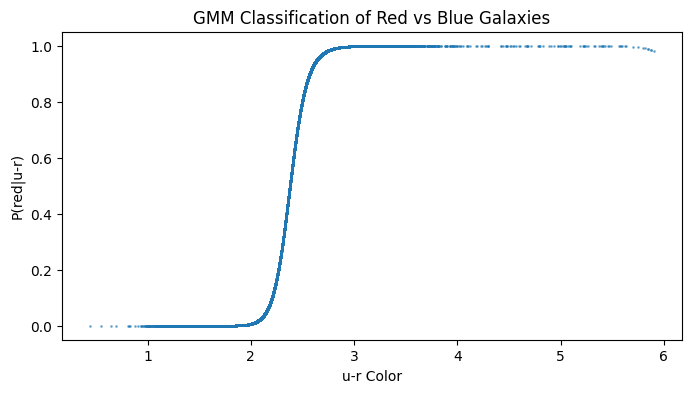

In [17]:
plt.figure(figsize=(8, 4))
plt.scatter(ds1[:,8], tau_red, s=1, alpha=0.5)
plt.xlabel('u-r Color') 
plt.ylabel('P(red|u-r)')
plt.title('GMM Classification of Red vs Blue Galaxies')

We know that there are 2 distinct clusters of galaxies, namely blue and red ones and theres a grey are in between called the green valley where both red and blue galaxies might live. Choosing N = 2, with 2 gaussians we are able to capture the green valley just as well if we were to fit a 3rd gaussian in the middle, N = 4 shows the best fit as it uses 2 gaussians with lower peaks to capture the edge cases and 2 with higher peaks to capture the more dense regions, statistically choosing N = 4 would be the best choice for estimating the empirical dist. however for interpratibility and for the classification purpose we are given in the task N = 2 makes more sense. Comparing the classification probabilities with the hard cut-off, we can see that the galaxies in the green valley region are not classified as red or blue with P=1, so we have now given them probabilities of belonging to each of the classes respectively.

Q4

In [41]:
model = KernelDensity(kernel='gaussian', bandwidth=h_opt)
Xdata = ds1[:, :2]  # RA and DEC
best_kde = model.fit(Xdata)
log_densities = best_kde.score_samples(Xdata)
rho_i = np.exp(log_densities)
ds1 = np.column_stack((ds1, rho_i))

In [38]:
# fit KDE on ds1
kde_task4 = KernelDensity(kernel='gaussian', bandwidth=h_opt)
model_task4 = kde_task4.fit(ds1[:, 0:2])

# get densities at each galaxy position
rho = np.exp(model_task4.score_samples(ds1[:, 0:2]))
q25 = np.percentile(rho, 25)
q75 = np.percentile(rho, 75)

# compute u-r color directly from raw columns
colors = ds1[:, 3] - ds1[:, 5]

# split by density
colors_low = (colors[rho < q25]).reshape(-1, 1)
colors_high = (colors[rho > q75]).reshape(-1, 1)

print(f"Median color in low density: {np.median(colors_low):.3f}")
print(f"Median color in high density: {np.median(colors_high):.3f}")

Median color in low density: 2.581
Median color in high density: 2.703


In [ ]:

q1, q3 = np.quantile(rho_i, [0.25, 0.75])
colors_low = ds1[rho_i <= q1, 8]   # Colors of galaxies in the loneliest areas
colors_high = ds1[rho_i >= q3, 8]  # Colors of galaxies in the crowded areas
print(f"Median color in loneliest areas: {np.median(colors_low):.2f}")
print(f"Median color in crowded areas: {np.median(colors_high):.2f}")

Median color in loneliest areas: 2.49
Median color in crowded areas: 2.76


In [33]:
def get_silverman_h(data):
    sigma = np.std(data)
    n = len(data)
    return 1.06 * sigma * (n**(-1/5))

# Fit the 1D KDE for the Low Density color distribution
h_low = get_silverman_h(colors_low)
Low_kde = KernelDensity(kernel='gaussian', bandwidth=h_low).fit(colors_low[:, np.newaxis])

# Fit the 1D KDE for the High Density color distribution
h_high = get_silverman_h(colors_high)
High_kde = KernelDensity(kernel='gaussian', bandwidth=h_high).fit(colors_high[:, np.newaxis])

In [34]:
from scipy.spatial.distance import jensenshannon
c_min = min(colors_low.min(), colors_high.min())
c_max = max(colors_low.max(), colors_high.max())
cgrid = np.linspace(c_min, c_max, 1000)
p_low = np.exp(Low_kde.score_samples(cgrid[:, np.newaxis]))
p_high = np.exp(High_kde.score_samples(cgrid[:, np.newaxis]))
dc = cgrid[1] - cgrid[0]

# Normalizing the distributions
p_low /= p_low.sum() * dc
p_high /= p_high.sum() * dc

# Calculating Jensen-Shannon Divergence
# The function returns sqrt(D_JS), so we square it [cite: 75]
D_JS = jensenshannon(p_low, p_high)**2
print(f"Jensen-Shannon Divergence between Low and High Density Color Distributions: {D_JS:.4f}")


Jensen-Shannon Divergence between Low and High Density Color Distributions: 0.0044


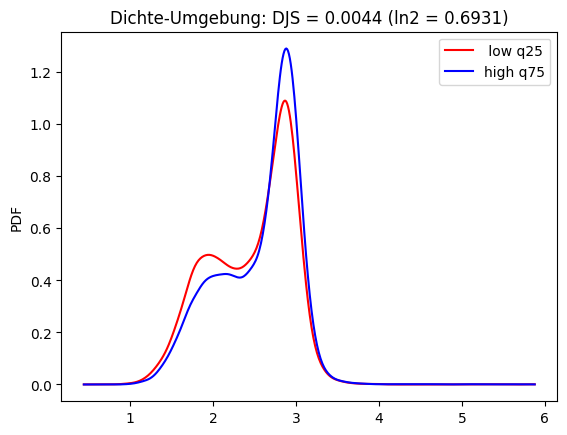

In [40]:
cgrid = np.linspace(c_min, c_max, 500)

p_low = np.exp(Low_kde.score_samples(cgrid[:,np.newaxis]))
p_high = np.exp(High_kde.score_samples(cgrid[:,np.newaxis]))
dc = cgrid[1]-cgrid[0]
p_low /= p_low.sum()*dc; p_high /= p_high.sum()*dc
D_JS = jensenshannon(p_low, p_high)**2 

#plot:

plt.plot(cgrid, p_low,  color='red',  label=' low q25')
plt.plot(cgrid, p_high, color='blue', label='high q75')
#plt.xlabel('ρ̂')
plt.ylabel('PDF')
plt.legend()
plt.title(f'Dichte-Umgebung: DJS = {D_JS:.4f} (ln2 = {np.log(2):.4f})')
plt.show()

In [22]:
print(f"Mean color in low density areas: {colors_low.mean():.3f}")
print(f"Mean color in high density areas: {colors_high.mean():.3f}")

Mean color in low density areas: 2.460
Mean color in high density areas: 2.548


Q5

In [23]:
redgalaxies_full = ds1[:, 8:9] > 2.3
bluegalaxies_full = ds1[:, 8:9] <= 2.3
redgalaxies_full = ds1[redgalaxies_full[:,0]]
bluegalaxies_full = ds1[bluegalaxies_full[:,0]]